In [1]:
from utils.vlm_worker import VLMWorker
import torch
import time
import argparse
import numpy as np
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
print("running inference test")
# --- Constants ---
MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
# MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

IMAGE_WIDTH = 640
IMAGE_HEIGHT = 480

class DataGenerator:
    """Generates synthetic turn data."""
    def __init__(self, width, height, processor):
        self.width = width
        self.height = height
        self.processor = processor

    def create_synthetic_image(self):
        arr = np.random.randint(0, 255, (self.height, self.width, 3), dtype=np.uint8)
        return Image.fromarray(arr)

    def _prepare_turn_inputs(self, step_idx):
        """
        Creates inputs for a SINGLE turn (Image + Text).
        We do not build the full conversation history in the prompt.
        We rely on the KV cache for history.
        """
        image = self.create_synthetic_image()
        import random
        # Construct a standalone prompt for this step
        # We simulate the user asking for a move
        actions = ["forward","left","right"]
        if step_idx>0:
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image","image":f"placeholder {step_idx}"},
                    ]
                },
                # We add the Assistant start token to force the model to predict the response immediately
                {"role": "assistant", "content": f"**{random.choice(actions)}**"} 
            ]
        else:
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text":"you are a navigation agent, choose the action from a sequence of images"},
                    ]
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "image","image":f"placeholder {step_idx}"},
                    ]
                },
                # We add the Assistant start token to force the model to predict the response immediately
                {"role": "assistant", "content": f"**{random.choice(actions)}**"} 
            ]
        return messages, [image]
    
    def prepare_sequence_inputs(self,turns):
        messages = []
        images = []
        for i in range(turns):
            message,image = self._prepare_turn_inputs(i)
            messages+=message
            images+=image
        return messages,images

def compare_kv_caches(gt_cache, chunked_cache,title=None):
    print("\n" + "="*30)
    print(f"COMPARISON RESULTS: {title}")
    print("="*30)
    
    max_diff = 0.0
    layers_checked = 0
    
    # Iterate through layers
    # (Qwen outputs tuples or DynamicCache, both act as iterables of (key, value))
    for i, (gt_layer, chunk_layer) in enumerate(zip(gt_cache, chunked_cache)):
        gt_k, gt_v = gt_layer
        ch_k, ch_v = chunk_layer
        
        # 1. Determine the target length from the chunked cache (the shorter one)
        # Shape is typically: [Batch, Num_Heads, Seq_Len, Head_Dim]
        # We assume Seq_Len is at index 2.
        chunk_len = ch_k.shape[2]
        
        # 2. Slice the GT cache to match the chunked length
        # We slice along the sequence dimension (dim=2)
        gt_k_sliced = gt_k[:, :, :chunk_len, :]
        gt_v_sliced = gt_v[:, :, :chunk_len, :]
        
        # 3. Compute absolute difference
        # Ensure tensors are on same device/dtype
        diff_k = (gt_k_sliced - ch_k).abs().max().item()
        diff_v = (gt_v_sliced - ch_v).abs().max().item()
        
        current_max = max(diff_k, diff_v)
        # print(f"at layer {i}, max diff is {current_max}")
        max_diff = max(max_diff, current_max)
        layers_checked += 1
        
        # Optional: Print shape info for the first layer to confirm slicing worked
        if i == 0:
            print(f"Layer 0 Shape Check:")
            print(f"  GT Original: {gt_k.shape}")
            print(f"  GT Sliced:   {gt_k_sliced.shape}")
            print(f"  Chunked:     {ch_k.shape}")

    print("-" * 30)
    print(f"Checked {layers_checked} layers.")
    print(f"Maximum absolute difference (L-inf norm): {max_diff:.8f}")
    
    # Typical FP16/BF16 tolerance is around 1e-3 to 1e-4
    if max_diff < 1e-3:
        print("✅ SUCCESS: The iterative cache matches the ground truth cache.")
    else:
        print("❌ WARNING: Significant divergence detected.")

import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_kv_diff_heatmap(gt_cache, chunked_cache):
    """
    Generates a 2D heatmap showing the max difference between GT and Chunked caches
    per layer and per sequence position.
    """
    print("Calculating cache differences per position...")
    
    # List to store the max difference vector for each layer
    heatmap_rows = []
    
    # Iterate over layers
    for layer_idx, (gt_layer, chunk_layer) in enumerate(zip(gt_cache, chunked_cache)):
        gt_k, gt_v = gt_layer
        ch_k, ch_v = chunk_layer
        
        # 1. Determine target length (chunked is the "cropped" version)
        # Shape: [Batch, Num_Heads, Seq_Len, Head_Dim]
        seq_len = ch_k.shape[2]
        
        # 2. Slice GT to match
        gt_k_sliced = gt_k[:, :, :seq_len, :]
        gt_v_sliced = gt_v[:, :, :seq_len, :]
        
        # 3. Calculate absolute differences
        # We want to reduce [Batch, Heads, Seq_Len, Dim] -> [Seq_Len]
        # We take the max over Batch(0), Heads(1), and Dim(3)
        
        # Difference for Keys
        diff_k = (gt_k_sliced - ch_k).abs()
        # Max across dimensions except Sequence (dim 2)
        # We flatten inputs to [Seq_Len, -1] then max over last dim for efficiency
        max_diff_k_per_token = diff_k.permute(2, 0, 1, 3).reshape(seq_len, -1).max(dim=1).values
        
        # Difference for Values
        diff_v = (gt_v_sliced - ch_v).abs()
        max_diff_v_per_token = diff_v.permute(2, 0, 1, 3).reshape(seq_len, -1).max(dim=1).values
        
        # 4. Take the worse of the two (Key or Value) for this layer
        layer_max_diffs = torch.max(max_diff_k_per_token, max_diff_v_per_token)
        
        # Move to CPU numpy for plotting
        heatmap_rows.append(layer_max_diffs.cpu().float().numpy())

    # Stack into a 2D array: Shape [Num_Layers, Seq_Len]
    data_matrix = np.stack(heatmap_rows)
    return data_matrix

def plot_heatmap_matplotlib(data_matrix):
    """
    Visualizes the cache difference matrix using pure Matplotlib.
    data_matrix: 2D numpy array of shape [Num_Layers, Seq_Len]
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 'aspect=auto' stretches the y-axis to fill the figure height
    # 'interpolation=nearest' ensures you see distinct pixels for each token/layer
    cax = ax.imshow(data_matrix, cmap='viridis', aspect='auto', interpolation='nearest')
    
    # Add colorbar with label
    cbar = fig.colorbar(cax, ax=ax)
    cbar.set_label('Max Absolute Difference')

    # Set titles and labels
    ax.set_title("KV Cache Divergence (Matplotlib Only)")
    ax.set_xlabel("Sequence Position (Token Index)")
    ax.set_ylabel("Layer Index")

    # Optional: Set ticks to be more readable
    # Show every 2nd layer on Y-axis
    ax.set_yticks(np.arange(0, data_matrix.shape[0], 2))
    
    # Show roughly 10 ticks on X-axis spread evenly
    step_x = max(1, data_matrix.shape[1] // 10)
    ax.set_xticks(np.arange(0, data_matrix.shape[1], step_x))

    plt.tight_layout()
    plt.show()

running inference test


In [ ]:
from tqdm import tqdm
USE_SPARSE=True
worker = VLMWorker(dtype='float32',use_sparse=USE_SPARSE)
# worker2 = VLMWorker(dtype='bfloat16',use_sparse=USE_SPARSE)
dg = DataGenerator(IMAGE_WIDTH,IMAGE_HEIGHT,worker.processor)


In [3]:
%load_ext autoreload
%autoreload 2
N=15
messages,images = dg.prepare_sequence_inputs(N)

with torch.no_grad():
    gt_inputs = worker.tokenize_inputs(messages,images).to(worker.model.device)
    gt_image_embeds = worker.model.get_image_features(gt_inputs['pixel_values'],gt_inputs['image_grid_thw'])
    gt_outputs = worker.model.forward(**gt_inputs,use_cache=True,save_image_db=True)
    gt_filtered_embeds = worker.model.model.language_model.kept_visual_embeds
    gt_cache = gt_outputs['past_key_values']

# with torch.no_grad():
#     inputs = worker2.tokenize_inputs(messages,images).to(worker.model.device)
#     control_outputs = worker2.model.forward(**inputs,use_cache=True)
#     ref_cache = control_outputs['past_key_values']

worker.reset()
for n in tqdm(range(N)):
    lower = 2*n
    upper = 2*n+3
    worker.infer_probs(messages[lower:upper],images[n])

chunked_cache = worker.past_key_values



keeping 2279/4500


  7%|▋         | 1/15 [00:00<00:01,  8.93it/s]

keeping 300/300
keeping 178/300
keeping 153/300


 33%|███▎      | 5/15 [00:00<00:00, 14.45it/s]

keeping 160/300
keeping 143/300
keeping 145/300
keeping 150/300


 60%|██████    | 9/15 [00:00<00:00, 15.65it/s]

keeping 132/300
keeping 137/300
keeping 147/300
keeping 142/300


 87%|████████▋ | 13/15 [00:00<00:00, 15.77it/s]

keeping 112/300
keeping 129/300
keeping 127/300
keeping 130/300


100%|██████████| 15/15 [00:00<00:00, 15.16it/s]


torch.Size([2312, 2048])

In [4]:
def compare_seq(a,b):
    seql= min(a.shape[-1],b.shape[-1])
    print(torch.count_nonzero(a[...,:seql].cpu()!=b[...,:seql].cpu()))
key = 'input_ids'
compare_seq(worker.cumulative_inputs[key],gt_inputs[key])

tensor(0)


In [38]:
gt_position_ids,_ = worker.model.model.get_rope_index(gt_inputs['input_ids'],gt_inputs['image_grid_thw'],None,gt_inputs['attention_mask'])
compare_seq(gt_position_ids,worker.cumulative_inputs['position_ids'])

tensor(0)


In [6]:
# compare_kv_caches(gt_cache,ref_cache,'gt cache with control cache of different dtype')
compare_kv_caches(gt_cache,chunked_cache,'gt cache with chunked cache of same dtype')


COMPARISON RESULTS: gt cache with chunked cache of same dtype
Layer 0 Shape Check:
  GT Original: torch.Size([1, 8, 2520, 128])
  GT Sliced:   torch.Size([1, 8, 2512, 128])
  Chunked:     torch.Size([1, 8, 2512, 128])
------------------------------
Checked 28 layers.
Maximum absolute difference (L-inf norm): 290.00000000
❌ WARNING: Significant divergence detected.


In [20]:
gt_mask = gt_outputs['seq_keep_mask']

tensor([True, True, True,  ..., True, True, True])

((tensor([[-0.1414, -0.3293, -0.9849,  ..., -0.6982, -0.0412,  0.6533],
          [-0.1385, -0.1990, -0.3054,  ..., -0.3567, -0.0273, -0.5044],
          [-0.0846,  0.1034,  0.1167,  ..., -0.2094,  0.1251, -0.2852],
          ...,
          [ 0.1702, -0.2430, -0.5840,  ..., -0.6899,  0.0031,  0.1678],
          [ 0.0499,  0.1379, -0.5190,  ..., -0.0630,  0.3987, -0.0930],
          [ 0.5718,  0.3184, -1.3193,  ..., -0.6968,  0.5498,  0.7896]],
         device='cuda:0', dtype=torch.float16),
  tensor([[ 0.0047, -0.2832, -0.8911,  ..., -0.6240,  0.0644,  0.9961],
          [ 0.0583, -0.0054, -0.2864,  ..., -0.2179, -0.1227, -0.7129],
          [-0.0817, -0.1061, -0.1307,  ..., -0.4685,  0.1310, -0.1819],
          ...,
          [ 0.1844,  0.0450,  0.0778,  ..., -0.1006,  0.2045, -0.1405],
          [ 0.0476,  0.2371, -0.5918,  ..., -0.7275,  0.1566, -0.4631],
          [ 0.8169,  0.0716, -1.2207,  ..., -0.9761,  0.7271,  0.9951]],
         device='cuda:0', dtype=torch.float16),
  tensor

In [56]:
print(torch.count_nonzero(worker.seq_keep_mask!=gt_outputs['seq_keep_mask'][:len(worker.seq_keep_mask)]))


tensor(54)


In [5]:
from utils.modeling import filter_embeds
normalized_first_image = torch.nn.functional.normalize(gt_image_embeds[0][0], p=2, dim=1)
rel_idx_to_keep, filtered_embeds =filter_embeds(gt_image_embeds[0],threshold=0.95)
db = None
for embed in gt_image_embeds[0]:
    rel_idx,filtered = filter_embeds([embed],db,threshold=0.95)
    if db is None:
        db = filtered
    else:
        db = torch.cat((db,filtered))

In [5]:
torch.linalg.norm(db-filtered_embeds)

tensor(0., device='cuda:0', dtype=torch.float16)

In [11]:
filtered_embeds.cpu()-gt_filtered_embeds[0].cpu()

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float16)

In [10]:
gt_filtered_embeds[0].cpu()[:300]-normalized_first_image.cpu()

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float16)

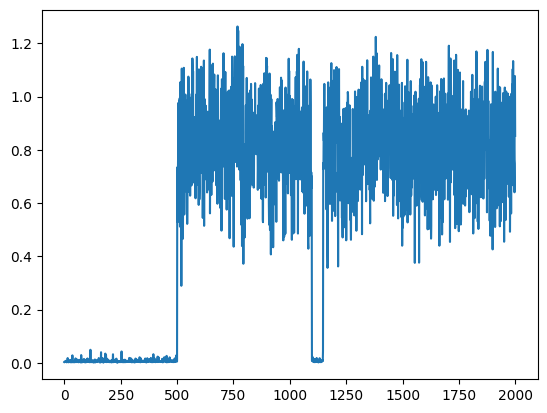

In [16]:
seql = 2000

norm = torch.linalg.norm(worker.past_image_embeds[0][:seql].cpu()-gt_filtered_embeds[0][:seql].cpu(),dim=-1)
import matplotlib.pyplot as plt
plt.plot(norm.cpu().numpy())

Calculating cache differences per position...


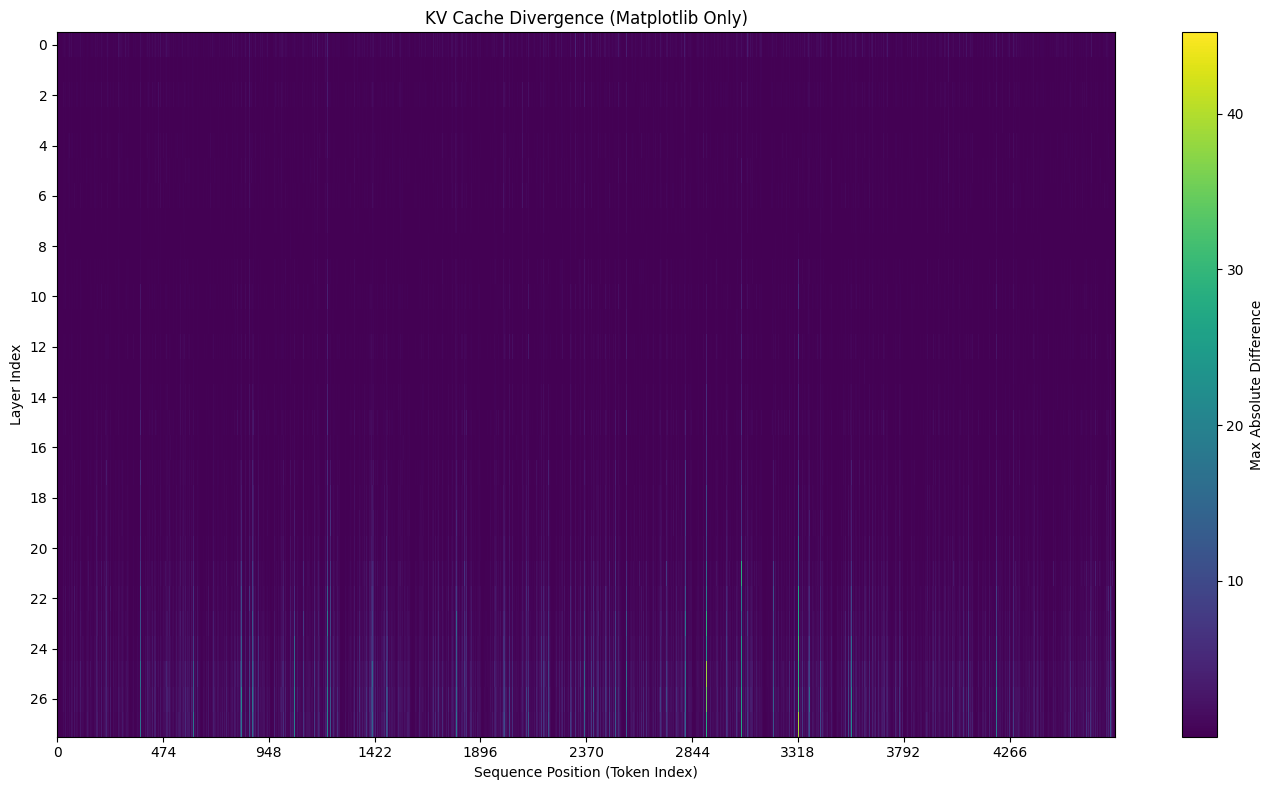

Calculating cache differences per position...


<Figure size 640x480 with 0 Axes>

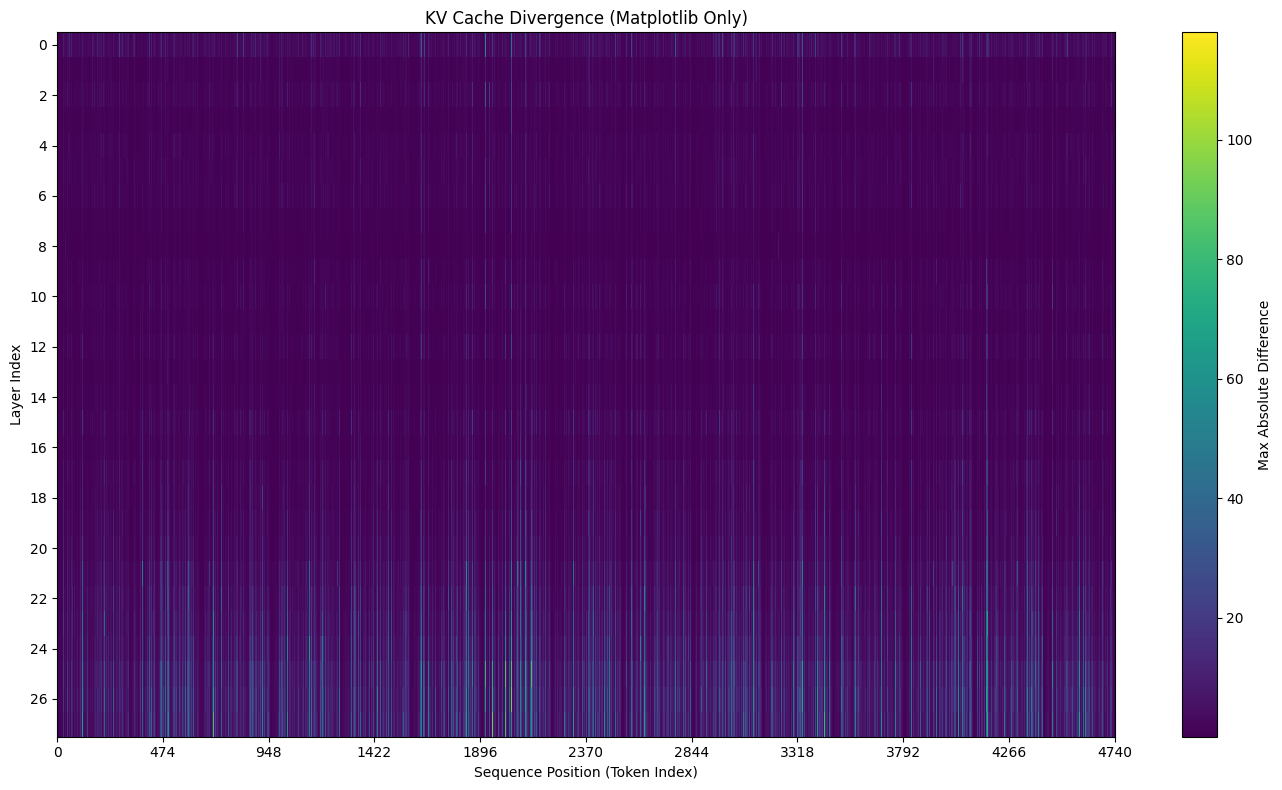

In [108]:


heatmap_data = visualize_kv_diff_heatmap(gt_cache, chunked_cache)
# Run the visualization
plot_heatmap_matplotlib(heatmap_data)

plt.figure()
heatmap_data = visualize_kv_diff_heatmap(gt_cache, ref_cache)
# Run the visualization
plot_heatmap_matplotlib(heatmap_data)